In [1]:
"""b3_fine_100classes.ipynb — EfficientNetB3 on CIFAR-100 FINE (100 classes)

Mirrors notebooks/b0_fine_100classes.ipynb and b7_fine_100classes.ipynb
structure. ONLY two configs: block6-unfreeze and full-unfreeze — no frozen
config, per instruction.

EfficientNetB3 backbone facts (measured at input_size=160):
  - 384 total layers (vs B0's 237, B7's 813)
  - 78 BatchNorm layers
  - block boundaries (layer index where each block starts):
        stem -> 3   block1 -> 7    block2 -> 29   block3 -> 73
        block4 -> 117   block5 -> 191   block6 -> 264   block7 -> 353   top -> 381
  - unfreeze_from="block6" trains the last 120 layers (~31% of network) —
    same sweet-spot ratio used for B0's and B7's block6 configs.
  - native/paper resolution is 300px; input_size=160 here is the practical
    CIFAR-appropriate compromise already used in the original B3 notebook
    (NOT forced to 300/native this time — only B7 had that explicit
    requirement).
"""

'b3_fine_100classes.ipynb — EfficientNetB3 on CIFAR-100 FINE (100 classes)\n\nMirrors notebooks/b0_fine_100classes.ipynb and b7_fine_100classes.ipynb\nstructure. ONLY two configs: block6-unfreeze and full-unfreeze — no frozen\nconfig, per instruction.\n\nEfficientNetB3 backbone facts (measured at input_size=160):\n  - 384 total layers (vs B0\'s 237, B7\'s 813)\n  - 78 BatchNorm layers\n  - block boundaries (layer index where each block starts):\n        stem -> 3   block1 -> 7    block2 -> 29   block3 -> 73\n        block4 -> 117   block5 -> 191   block6 -> 264   block7 -> 353   top -> 381\n  - unfreeze_from="block6" trains the last 120 layers (~31% of network) —\n    same sweet-spot ratio used for B0\'s and B7\'s block6 configs.\n  - native/paper resolution is 300px; input_size=160 here is the practical\n    CIFAR-appropriate compromise already used in the original B3 notebook\n    (NOT forced to 300/native this time — only B7 had that explicit\n    requirement).\n'

In [2]:
import os

repo_name = "deepl-cifar100-image-analysis"
if not os.path.exists(repo_name):
    os.system(f'git clone https://github.com/Fgram-devAI/{repo_name}.git')
else:
    print(f'Repository "{repo_name}" already exists. Skipping clone.')

## Change directory

In [4]:
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


In [5]:
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


In [6]:
!git checkout experiment/efficientnet-b0-fine
!git pull origin experiment/efficientnet-b0-fine
!git checkout -b experiment/efficientnet-b3-fine
!pwd
!git status

Branch 'experiment/efficientnet-b0-fine' set up to track remote branch 'experiment/efficientnet-b0-fine' from 'origin'.
Switched to a new branch 'experiment/efficientnet-b0-fine'
From https://github.com/Fgram-devAI/deepl-cifar100-image-analysis
 * branch            experiment/efficientnet-b0-fine -> FETCH_HEAD
Already up to date.
Switched to a new branch 'experiment/efficientnet-b3-fine'
/content/deepl-cifar100-image-analysis
On branch experiment/efficientnet-b3-fine
nothing to commit, working tree clean


## Check library versions

In [7]:
import sklearn, numpy
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
numpy: 2.0.2


## Define EfficientNetB3 model

In [8]:
%%writefile models/efficientnet_b3_fine.py
"""EfficientNetB3 transfer-learning model for CIFAR-100 multiclass tasks."""

import tensorflow as tf

from models.augmentation import build_augmentation

keras = tf.keras
layers = tf.keras.layers

# EfficientNetB3 backbone has 384 layers total (vs B0's 237, B7's 813),
# grouped into 7 MBConv blocks plus stem/top. Layer-index where each block
# starts (measured at input_size=160; stable across input sizes since it's
# topology, not shape, that determines block boundaries):
#   stem -> 3   block1 -> 7   block2 -> 29   block3 -> 73   block4 -> 117
#   block5 -> 191   block6 -> 264   block7 -> 353   top -> 381   (384 total)
# unfreeze_from="block6" leaves the first ~69% frozen and trains the last
# ~120 layers (block6, block7, top) — same sweet-spot ratio as B0/B7's
# block6 configs (~30% of the network trainable).


def build_efficientnet_b3(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 100,
    dropout: float = 0.4,
    freeze_backbone: bool = True,
    unfreeze_from: str | None = None,   # None | "all" | "block5" | "block6" | "block7"
    freeze_bn: bool = True,             # keep BatchNorm stats frozen (recommended)
    input_size: int = 160,              # B3's native res is 300; 160 is a practical CIFAR compromise
    augmentation: dict | None = None,
) -> keras.Model:
    """EfficientNetB3 classifier for CIFAR-100.

    Same structure/semantics as build_efficientnet_b0 / build_efficientnet_b7.
    """
    if num_classes < 1:
        raise ValueError(f"num_classes must be >= 1; got {num_classes}")

    inputs = keras.Input(shape=input_shape, name="image")

    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)
    x = layers.Rescaling(255.0)(x)

    backbone = keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        if unfreeze_from not in (None, "all"):
            trainable = False
            for layer in backbone.layers:
                if layer.name.startswith(unfreeze_from):
                    trainable = True
                layer.trainable = trainable
        if freeze_bn:
            for layer in backbone.layers:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

    backbone_is_fully_frozen = freeze_backbone
    x = backbone(x, training=not backbone_is_fully_frozen)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b3")

Writing models/efficientnet_b3_fine.py


## Patch models/__init__.py

In [9]:
import pathlib

p = pathlib.Path("models/__init__.py")
src = p.read_text()
original_src = src

needs_patch = "from .efficientnet_b3_fine import build_efficientnet_b3" not in original_src

if needs_patch:
    src = src.replace(
        "from .efficientnet_b0 import build_efficientnet_b0\n",
        "from .efficientnet_b0 import build_efficientnet_b0\n"
        "from .efficientnet_b3_fine import build_efficientnet_b3\n",
    )
    src = src.replace(
        '    "build_efficientnet_b0",\n',
        '    "build_efficientnet_b0",\n'
        '    "build_efficientnet_b3",\n',
    )
    p.write_text(src)
    print("models/__init__.py patched (now exports build_efficientnet_b3).")
else:
    print("models/__init__.py already exports build_efficientnet_b3.")

!grep -n efficientnet models/__init__.py

models/__init__.py patched (now exports build_efficientnet_b3).
4:from .efficientnet_b0 import build_efficientnet_b0
5:from .efficientnet_b3_fine import build_efficientnet_b3
12:    "build_efficientnet_b0",
13:    "build_efficientnet_b3",


## Patch training/train.py

In [10]:
p = pathlib.Path("training/train.py")
src = p.read_text()
original_src = src  # pristine copy — checks run against this, never against
                     # a partially-mutated `src` (see the vit_pretrained bug
                     # earlier in this project for why this matters)

needs_import_patch = "from models.efficientnet_b3_fine import build_efficientnet_b3" not in original_src

old_anchor = '''    if architecture == "efficientnet_b0":
        return build_efficientnet_b0(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            freeze_backbone=bool(config.get("freeze_backbone", True)),
            unfreeze_from=config.get("unfreeze_from"),
            freeze_bn=bool(config.get("freeze_bn", True)),
            input_size=int(config.get("input_size", 96)),
            augmentation=config.get("augmentation"),
        )'''

new_block = '''    if architecture == "efficientnet_b0":
        return build_efficientnet_b0(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            freeze_backbone=bool(config.get("freeze_backbone", True)),
            unfreeze_from=config.get("unfreeze_from"),
            freeze_bn=bool(config.get("freeze_bn", True)),
            input_size=int(config.get("input_size", 96)),
            augmentation=config.get("augmentation"),
        )
    if architecture == "efficientnet_b3":
        return build_efficientnet_b3(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            freeze_backbone=bool(config.get("freeze_backbone", True)),
            unfreeze_from=config.get("unfreeze_from"),
            freeze_bn=bool(config.get("freeze_bn", True)),
            input_size=int(config.get("input_size", 160)),
            augmentation=config.get("augmentation"),
        )'''

needs_build_model_patch = old_anchor in original_src and "efficientnet_b3" not in original_src

if needs_import_patch:
    src = src.replace(
        "from models.efficientnet_b0 import build_efficientnet_b0\n",
        "from models.efficientnet_b0 import build_efficientnet_b0\n"
        "from models.efficientnet_b3_fine import build_efficientnet_b3\n",
    )

if needs_build_model_patch:
    assert old_anchor in src, "train.py upstream changed again — patch needs review"
    src = src.replace(old_anchor, new_block)

if needs_import_patch or needs_build_model_patch:
    p.write_text(src)
    print("train.py patched (now supports efficientnet_b3, alongside efficientnet_b0).")
else:
    print("train.py already supports efficientnet_b3.")

!grep -n efficientnet_b3 training/train.py

train.py patched (now supports efficientnet_b3, alongside efficientnet_b0).
30:from models.efficientnet_b3_fine import build_efficientnet_b3
62:    if architecture == "efficientnet_b3":
63:        return build_efficientnet_b3(


## Write EfficientNetB3 block6 unfreeze config

In [11]:
%%writefile configs/multiclass/efficientnet_b3_fine_unfreeze_block6.yaml
architecture: efficientnet_b3
run_name: efficientnet_b3_fine_unfreeze_block6_in160_ep35
seed: 42

task:
  type: multiclass
  label_level: fine

validation:
  fraction: 0.1

class_imbalance:
  strategy: none

batch_size: 32              # B3 is heavier than B0 — drop batch size to avoid OOM
shuffle_buffer: 4096
dropout: 0.4
epochs: 35
optimizer: adam
learning_rate: 1e-4

freeze_backbone: false
unfreeze_from: block6        # trains the last ~120/384 layers (~31%)
freeze_bn: true
input_size: 160              # practical compromise; B3's native res is 300

augmentation:
  enabled: true
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 10

output_dir: results/efficientnet_b3_fine_unfreeze_block6
save_weights: true
subset_size: null

Writing configs/multiclass/efficientnet_b3_fine_unfreeze_block6.yaml


## Write EfficientNetB3 full fine-tuning config

In [12]:
%%writefile configs/multiclass/efficientnet_b3_fine_ft.yaml
architecture: efficientnet_b3
run_name: efficientnet_b3_fine_ft_in160_ep40
seed: 42

task:
  type: multiclass
  label_level: fine

validation:
  fraction: 0.1

class_imbalance:
  strategy: none

batch_size: 16               # smaller still — ALL 384 layers trainable
shuffle_buffer: 4096
dropout: 0.4
epochs: 40
optimizer: adam
learning_rate: 1e-5           # CRITICAL: very low LR — all 12M params unfrozen

freeze_backbone: false
unfreeze_from: all
freeze_bn: true
input_size: 160

augmentation:
  enabled: true
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 10

output_dir: results/efficientnet_b3_fine_ft
save_weights: true
subset_size: null

Writing configs/multiclass/efficientnet_b3_fine_ft.yaml


## Verify patches and configs

In [13]:
!grep -n efficientnet_b3 models/__init__.py
!grep -n efficientnet_b3 training/train.py
!ls configs/multiclass/ | grep b3

5:from .efficientnet_b3_fine import build_efficientnet_b3
13:    "build_efficientnet_b3",
30:from models.efficientnet_b3_fine import build_efficientnet_b3
62:    if architecture == "efficientnet_b3":
63:        return build_efficientnet_b3(
efficientnet_b3_fine_ft.yaml
efficientnet_b3_fine_unfreeze_block6.yaml


## Install tf_keras and set TF_USE_LEGACY_KERAS

In [14]:
!pip install -q tf_keras
os.environ["TF_USE_LEGACY_KERAS"] = "1"

## Run training for block6 unfreeze config

In [15]:
!python -m training.train --config configs/multiclass/efficientnet_b3_fine_unfreeze_block6.yaml

README.md: 100% 9.98k/9.98k [00:00<00:00, 4.93MB/s]
cifar100/train-00000-of-00001.parquet: 100% 119M/119M [00:02<00:00, 48.3MB/s]
cifar100/test-00000-of-00001.parquet: 100% 23.8M/23.8M [00:01<00:00, 22.0MB/s]
Generating train split: 100% 50000/50000 [00:00<00:00, 99018.53 examples/s]
Generating test split: 100% 10000/10000 [00:00<00:00, 71254.99 examples/s]
2026-06-21 15:11:51.000212: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782054711.001725    1076 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-21 15:11:51.002694: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-21 15:11:51.512741: W external/local_xla/xl

## Run training for full fine-tuning config

In [16]:
!python -m training.train --config configs/multiclass/efficientnet_b3_fine_ft.yaml

2026-06-21 15:48:39.139997: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782056919.141590   10739 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-21 15:48:39.142629: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-21 15:48:39.657482: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-21 15:48:47.838628: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
Epoch 1/40
E0000 00:00:1782056940.033013   10739 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Si

## List output files for both runs

In [17]:
!find results/efficientnet_b3_fine_unfreeze_block6/ -type f
!find results/efficientnet_b3_fine_ft/ -type f

results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/history.json
results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/metrics.json
results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/config.yaml
results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/class_balance.json
results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/history.csv
results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35/weights.h5
results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/history.json
results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/metrics.json
results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/config.yaml
results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/class_balance.json
results/efficientnet_b3_fine_ft/effic

## List contents of block6 unfreeze run directory

In [18]:
from pathlib import Path
run_dir = Path("results/efficientnet_b3_fine_unfreeze_block6/efficientnet_b3_fine_unfreeze_block6_in160_ep35")
os.system(f'ls -la {run_dir}')

0

## Load and display metrics for block6 unfreeze run

In [19]:
import json

with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("History keys:", list(history.keys()))
print("=== Final test metrics (fine / 100 classes, B3 block6 unfreeze) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

History keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']
=== Final test metrics (fine / 100 classes, B3 block6 unfreeze) ===
Accuracy:        0.7819
Top-3 accuracy:  0.9287
Top-5 accuracy:  0.9619
Macro precision: 0.7936
Macro recall:    0.7819
Macro F1:        0.7806
Weighted F1:     0.7806


## Save block6 unfreeze metrics to summary CSV

In [20]:
import csv

summary_path = Path("results/summary.csv")
COLUMNS = ["task_name", "run_name", "task_type", "label_level", "target_labels",
           "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold",
           "top_3_accuracy", "top_5_accuracy", "macro_f1", "weighted_f1"]

row = {c: "" for c in COLUMNS}
row.update({
    "task_name": run_dir.parent.name,
    "run_name": run_dir.name,
    "task_type": "multiclass",
    "label_level": "fine",
    "accuracy": metrics.get("accuracy", ""),
    "top_3_accuracy": metrics.get("top_3_accuracy", ""),
    "top_5_accuracy": metrics.get("top_5_accuracy", ""),
    "macro_f1": metrics.get("macro_f1", ""),
    "weighted_f1": metrics.get("weighted_f1", ""),
})

write_header = not summary_path.exists()
with summary_path.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=COLUMNS)
    if write_header:
        w.writeheader()
    w.writerow(row)
print(f"Appended {row['run_name']} to {summary_path}")

Appended efficientnet_b3_fine_unfreeze_block6_in160_ep35 to results/summary.csv


## Plot training curves for block6 unfreeze run

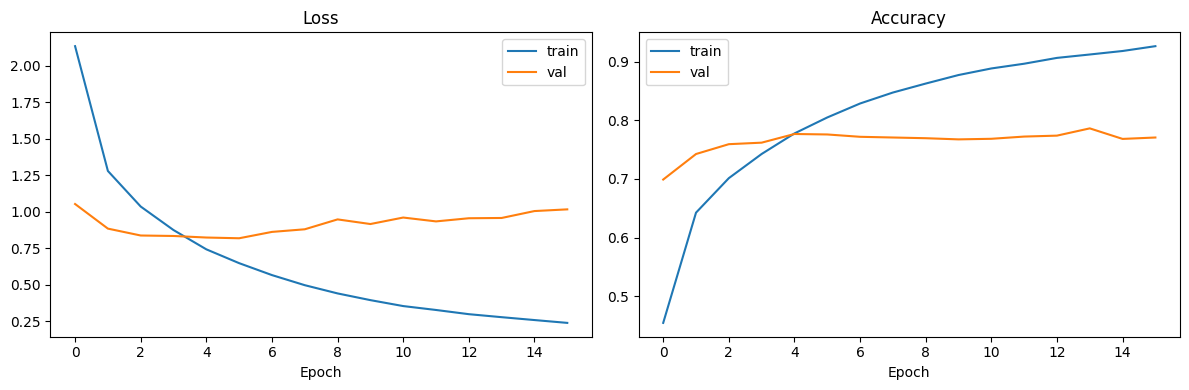

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

## Define CIFAR-100 fine labels

In [22]:
FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]
assert len(FINE_LABELS) == 100

## Plot confusion matrix and worst classes for block6 unfreeze run

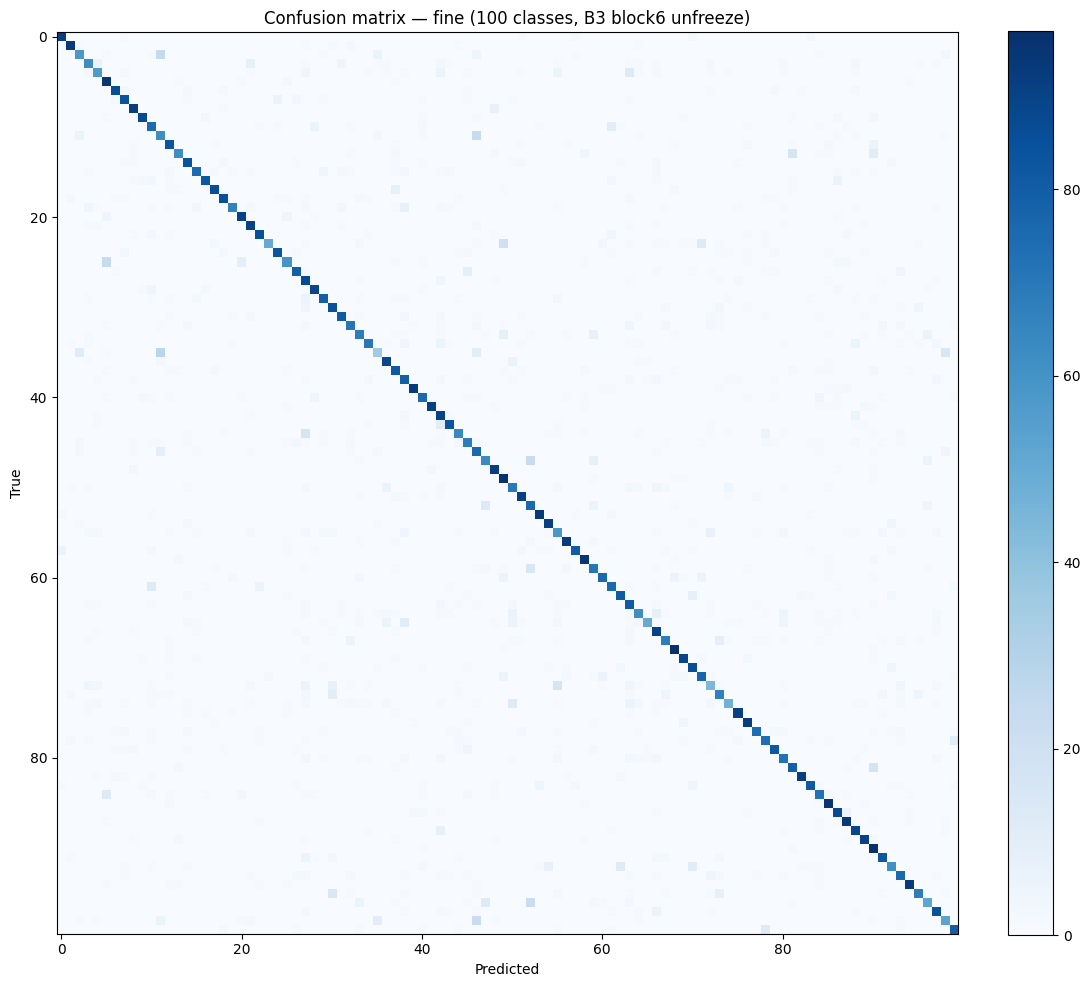

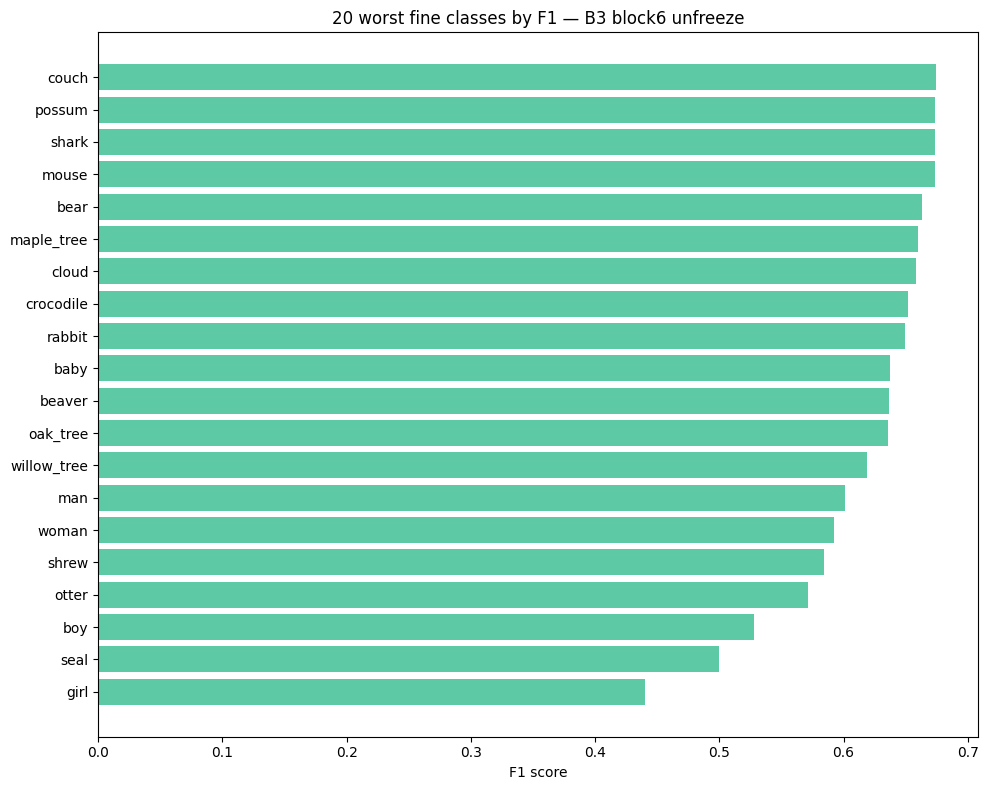

In [23]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes, B3 block6 unfreeze)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

diag = np.diag(cm)
col_sums = cm.sum(axis=0); row_sums = cm.sum(axis=1)
precision = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(diag, float), where=(precision + recall) != 0)

worst = np.argsort(f1)[:20]
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(worst))
ax.barh(y, f1[worst], color="#5DCAA5")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst])
ax.set_xlabel("F1 score"); ax.set_title("20 worst fine classes by F1 — B3 block6 unfreeze")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1_worst20.png", dpi=150)
plt.show()

## Analyze misclassified examples for block6 unfreeze run

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(10000, 32, 32, 3) (10000,)
313/313 [==============================] - 22s 55ms/step


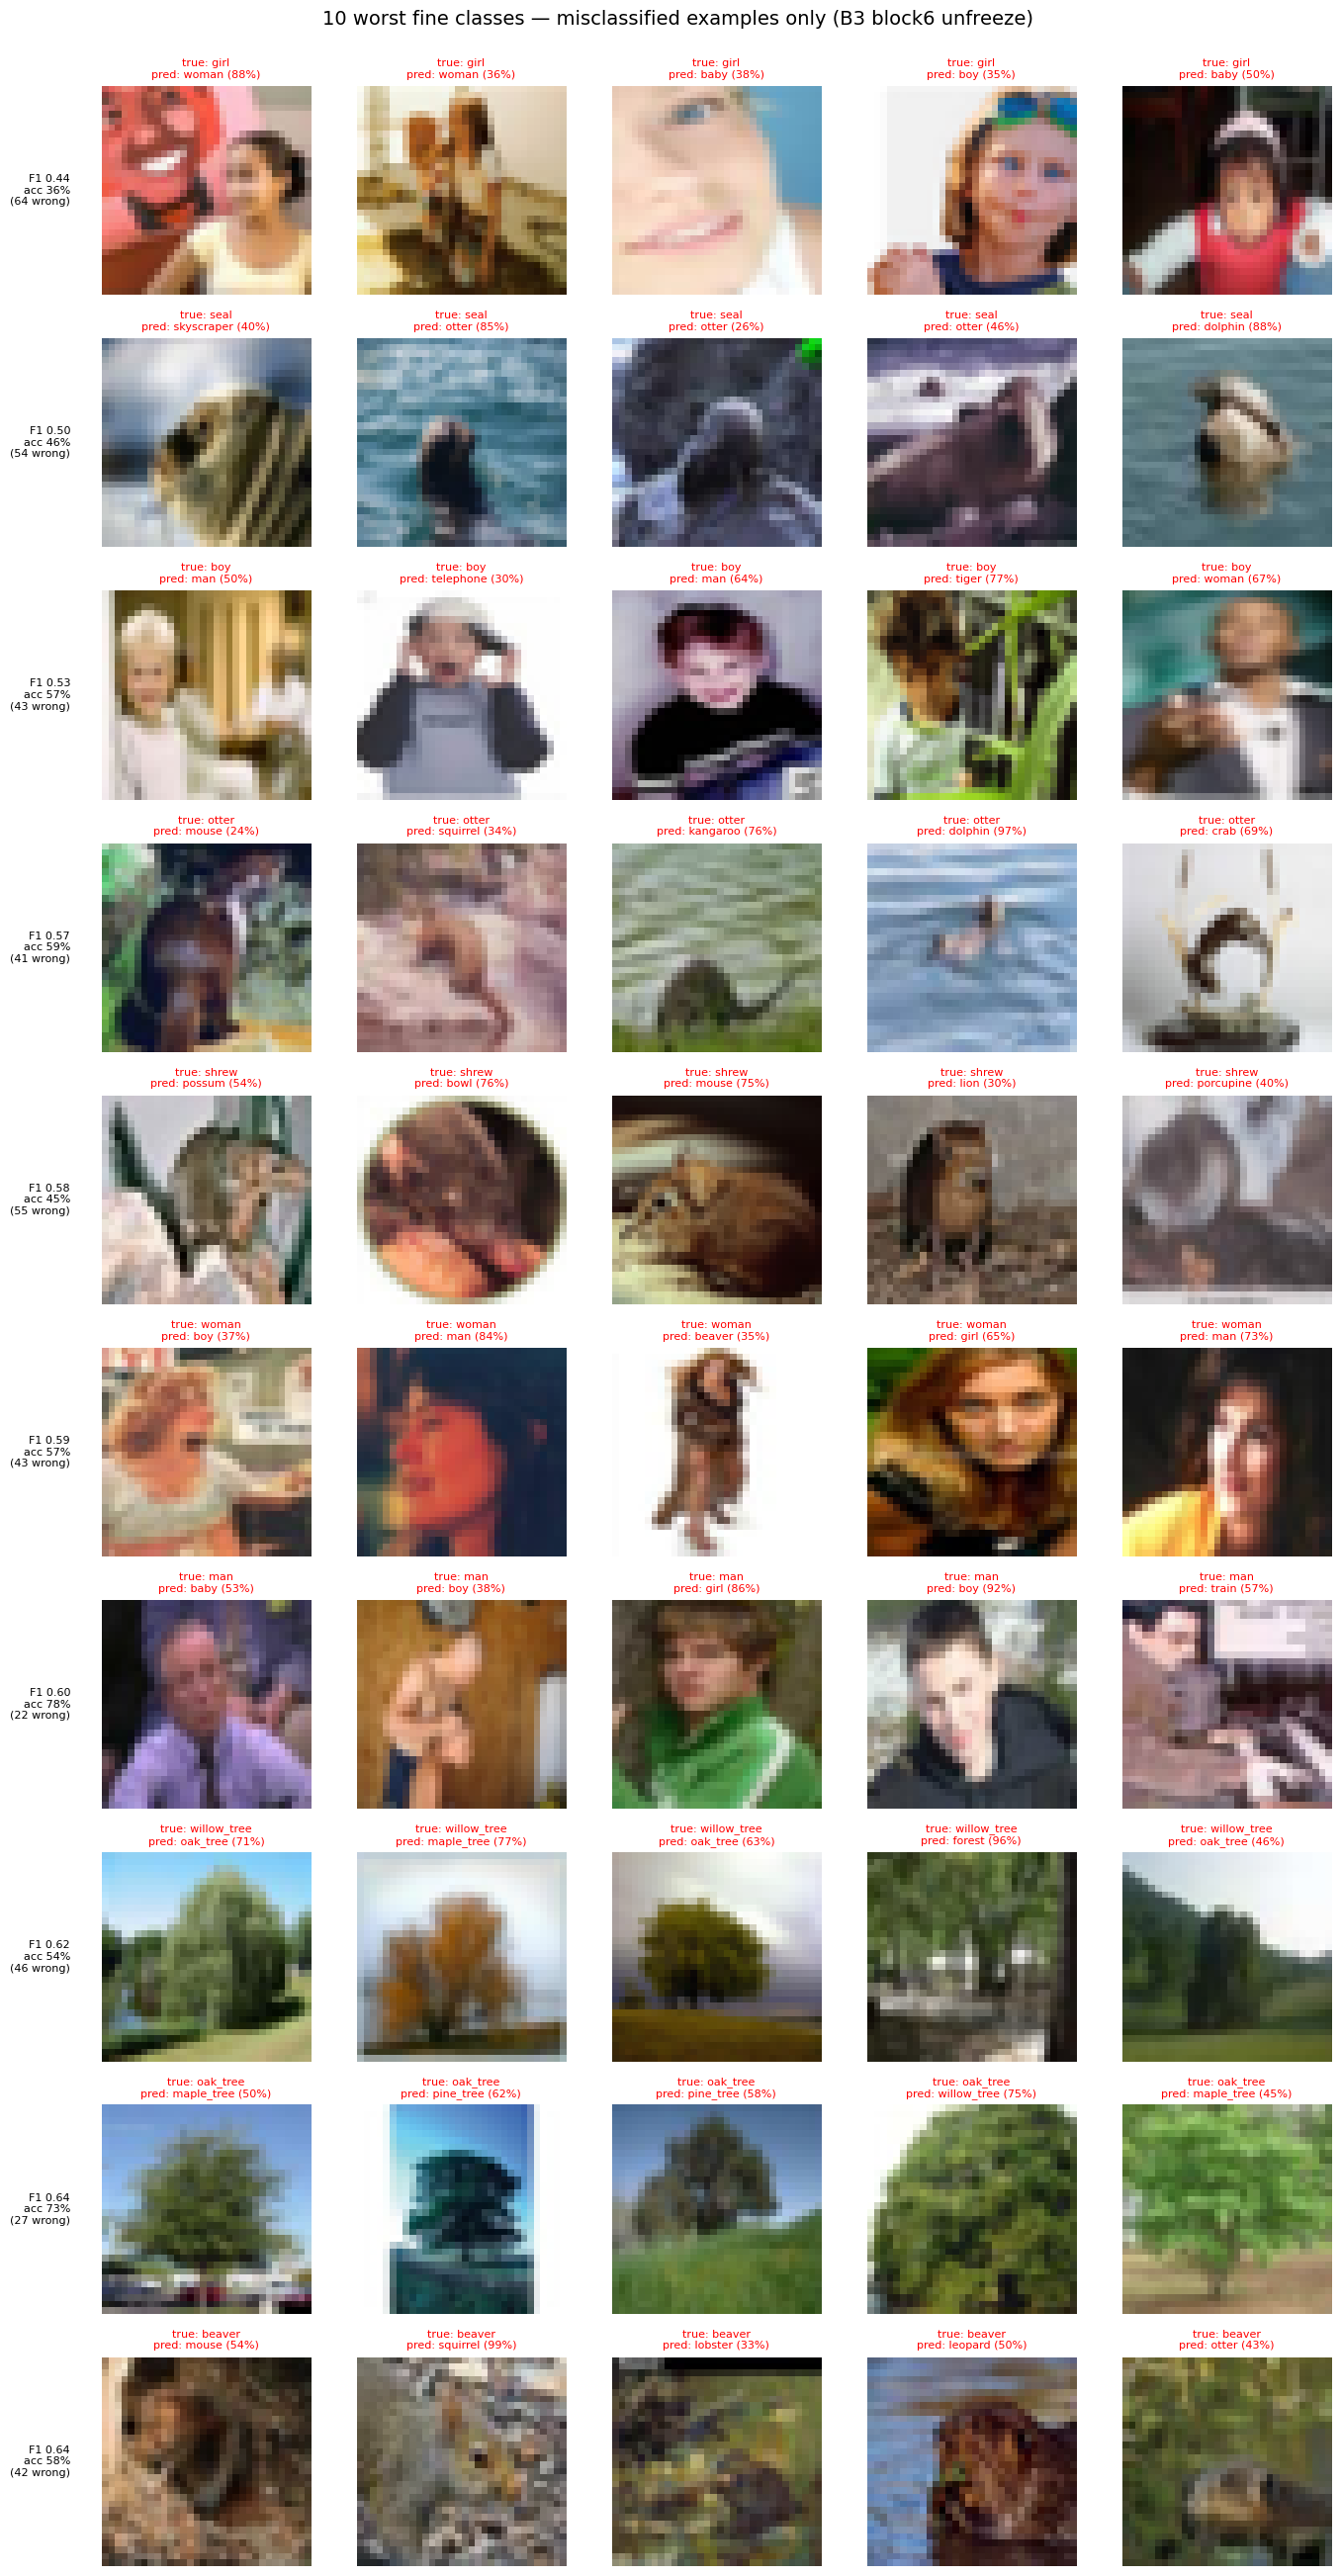

In [24]:
from data import load_cifar100
from data.tasks import make_cifar100_multiclass_task
from models.efficientnet_b3_fine import build_efficientnet_b3

test_split = load_cifar100("test")
test_task = make_cifar100_multiclass_task(test_split, label_level="fine", seed=42)
test_images = test_task.images
test_labels = test_task.labels
print(test_images.shape, test_labels.shape)

# Must match CONFIG A exactly: freeze_backbone=False, unfreeze_from="block6"
model = build_efficientnet_b3(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="block6",
    freeze_bn=True,
    input_size=160,
)
model.load_weights(run_dir / "weights.h5")

test_images_normalized = test_images.astype(np.float32) / 255.0
probs = model.predict(test_images_normalized, batch_size=32, verbose=1)
preds = probs.argmax(axis=1)
confidences = probs.max(axis=1)

worst10 = worst[:10]
fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst10):
    category = FINE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))

    acc = (preds[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {FINE_LABELS[preds[idx]]} ({confidences[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5, f"F1 {f1[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                     transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst fine classes — misclassified examples only (B3 block6 unfreeze)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir / "worst10_misclassified.png", dpi=150)
plt.show()

## List contents of full fine-tuning run directory

In [25]:
run_dir = Path("results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40")
os.system(f'ls -la {run_dir}')

0

## Load and display metrics for full fine-tuning run, and save to summary CSV

In [26]:
with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("=== Final test metrics (fine / 100 classes, B3 full unfreeze) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

row = {c: "" for c in COLUMNS}
row.update({
    "task_name": run_dir.parent.name,
    "run_name": run_dir.name,
    "task_type": "multiclass",
    "label_level": "fine",
    "accuracy": metrics.get("accuracy", ""),
    "top_3_accuracy": metrics.get("top_3_accuracy", ""),
    "top_5_accuracy": metrics.get("top_5_accuracy", ""),
    "macro_f1": metrics.get("macro_f1", ""),
    "weighted_f1": metrics.get("weighted_f1", ""),
})
with summary_path.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=COLUMNS)
    w.writerow(row)
print(f"Appended {row['run_name']} to {summary_path}")

=== Final test metrics (fine / 100 classes, B3 full unfreeze) ===
Accuracy:        0.8321
Top-3 accuracy:  0.9524
Top-5 accuracy:  0.9738
Macro F1:        0.8319
Weighted F1:     0.8319
Appended efficientnet_b3_fine_ft_in160_ep40 to results/summary.csv


## Plot training curves for full fine-tuning run

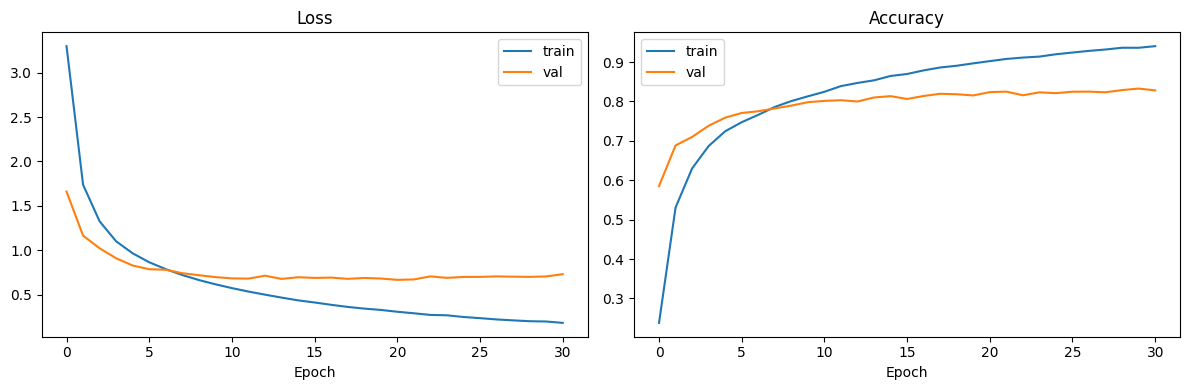

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

## Plot confusion matrix and worst classes for full fine-tuning run

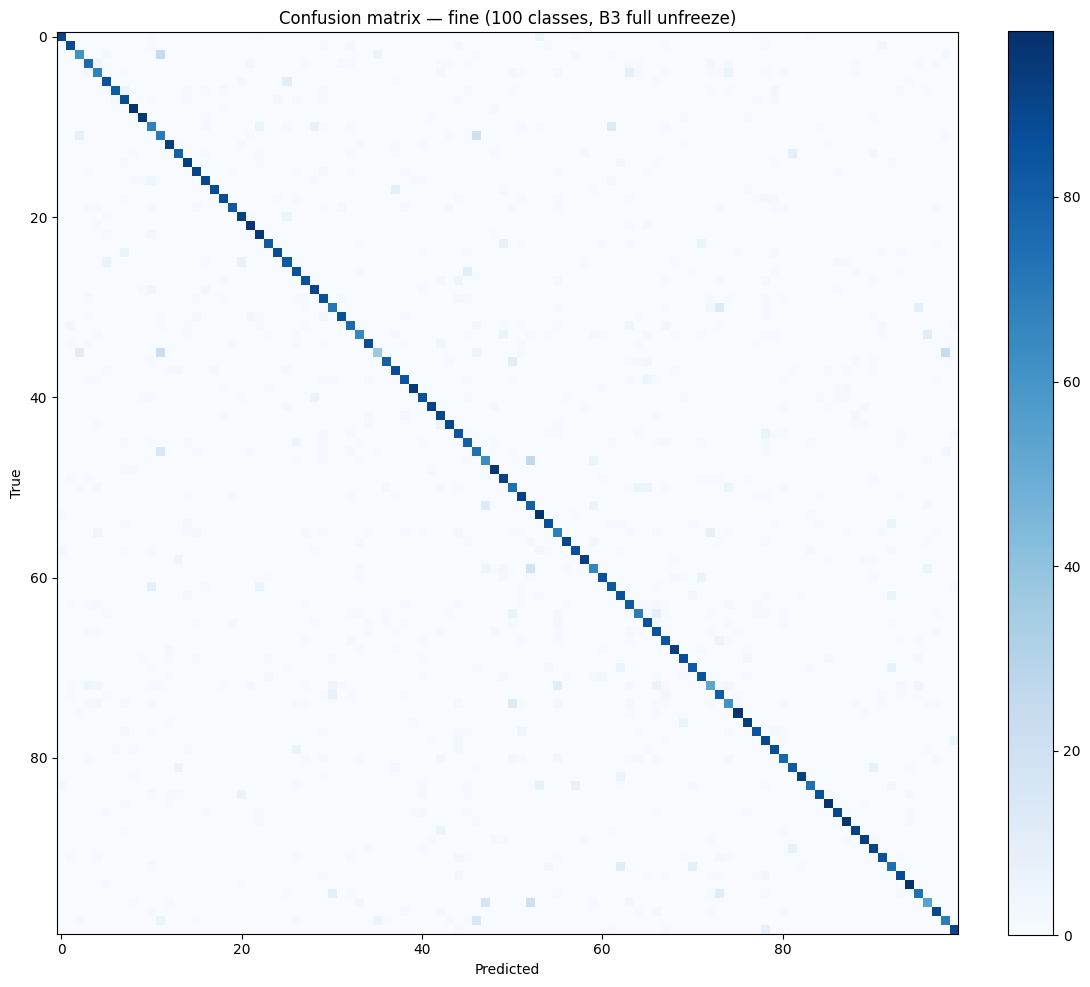

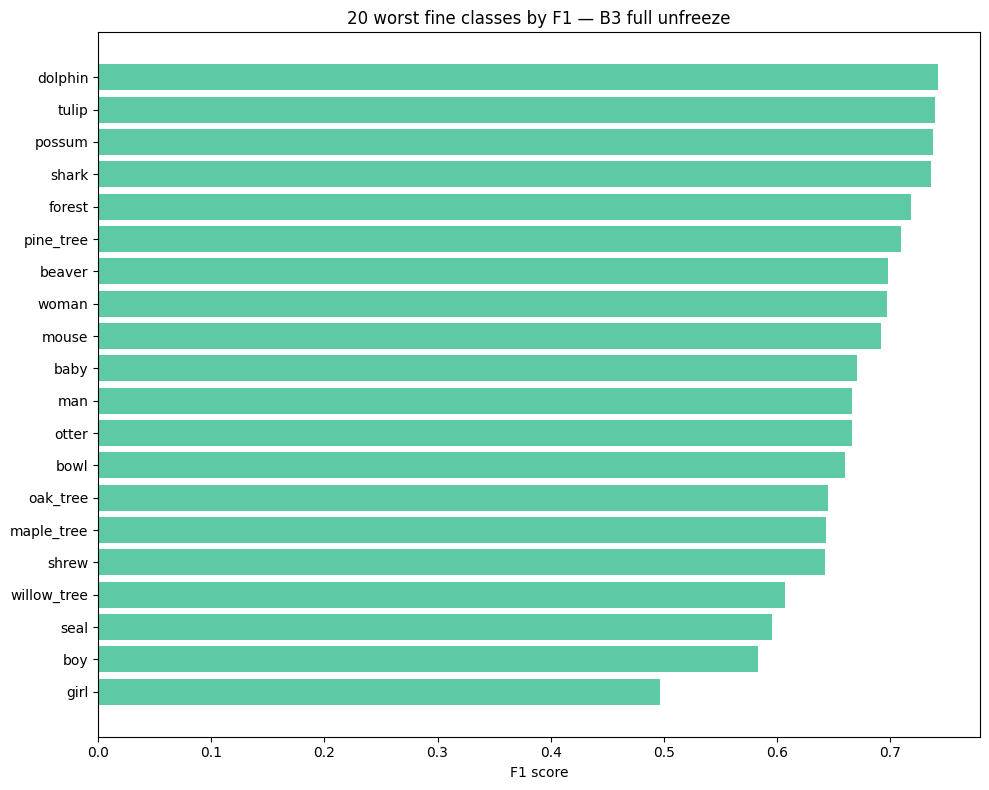

In [28]:
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes, B3 full unfreeze)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

diag = np.diag(cm)
col_sums = cm.sum(axis=0); row_sums = cm.sum(axis=1)
precision = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(diag, float), where=(precision + recall) != 0)

worst = np.argsort(f1)[:20]
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(worst))
ax.barh(y, f1[worst], color="#5DCAA5")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst])
ax.set_xlabel("F1 score"); ax.set_title("20 worst fine classes by F1 — B3 full unfreeze")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1_worst20.png", dpi=150)
plt.show()

## Analyze misclassified examples for full fine-tuning run

625/625 [==============================] - 20s 29ms/step


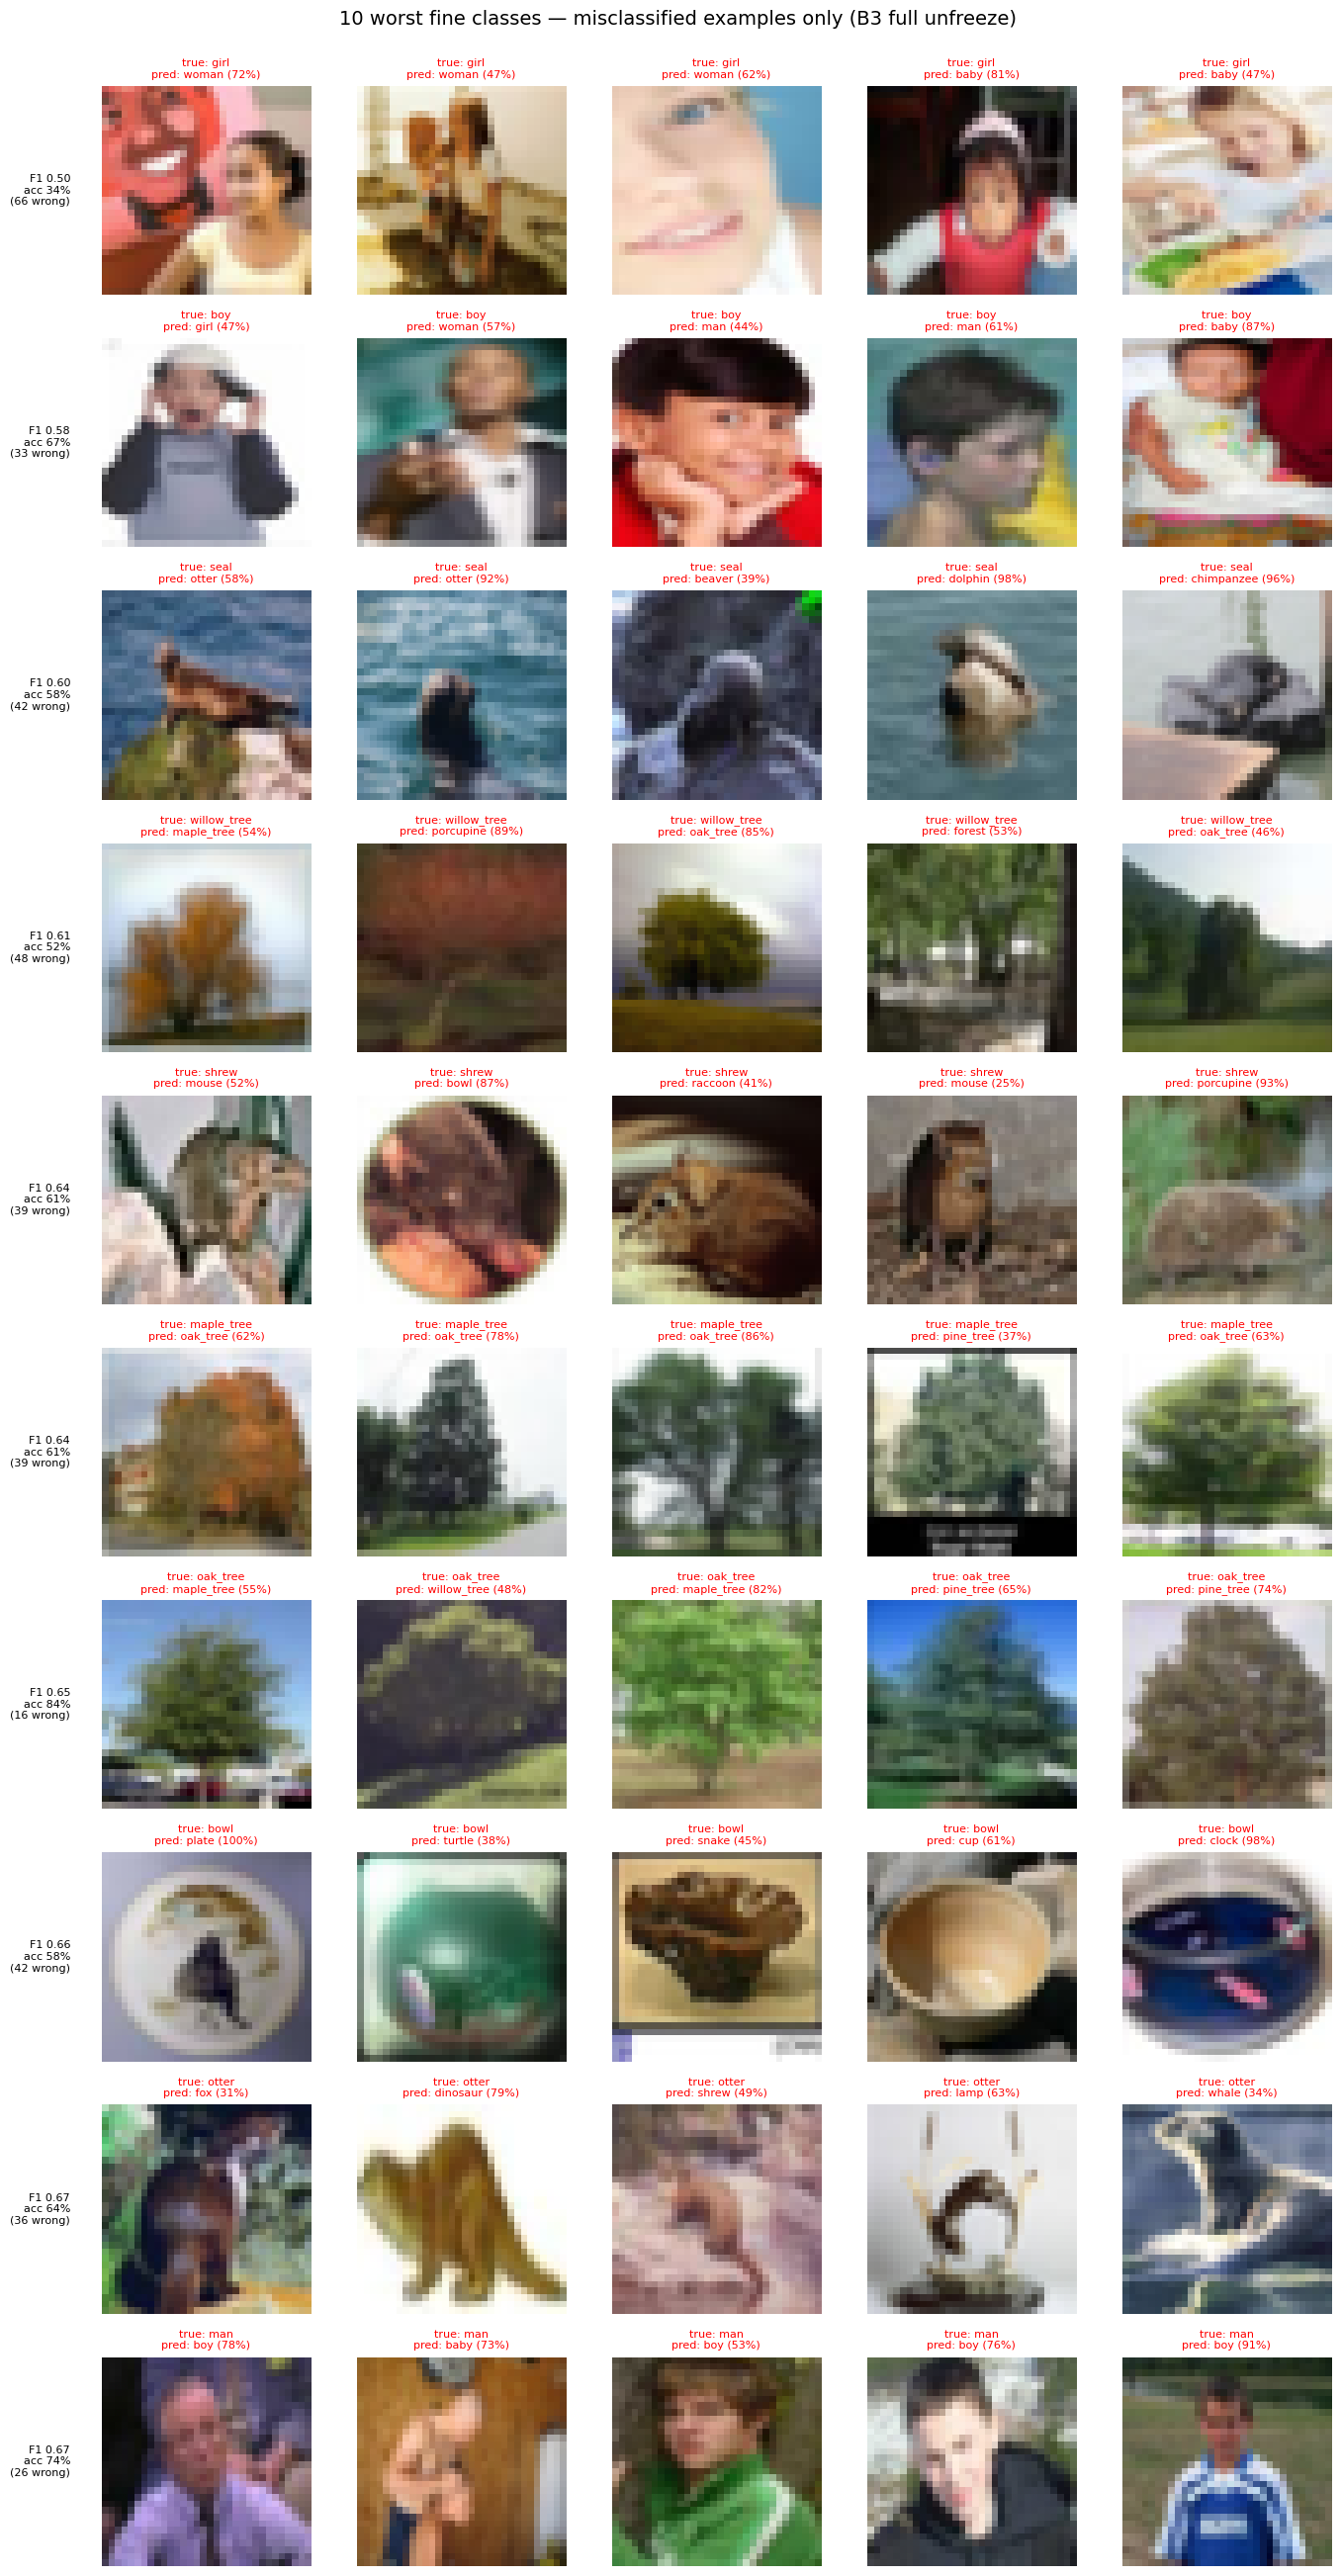

In [29]:
model = build_efficientnet_b3(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="all",
    freeze_bn=True,
    input_size=160,
)
model.load_weights(run_dir / "weights.h5")

probs = model.predict(test_images_normalized, batch_size=16, verbose=1)
preds = probs.argmax(axis=1)
confidences = probs.max(axis=1)

worst10 = worst[:10]
fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst10):
    category = FINE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))

    acc = (preds[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {FINE_LABELS[preds[idx]]} ({confidences[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5, f"F1 {f1[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                     transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst fine classes — misclassified examples only (B3 full unfreeze)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir / "worst10_misclassified.png", dpi=150)
plt.show()

## Configure Git user

In [30]:
!git config --global user.email "thcoccas@gmail.com"
!git config --global user.name "ThodorisKokkas"

## Stage changes for Git commit

In [31]:
!git add -A
!git add -f results/efficientnet_b3_fine_unfreeze_block6/ results/efficientnet_b3_fine_ft/
!git status

On branch experiment/efficientnet-b3-fine
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   configs/multiclass/efficientnet_b3_fine_ft.yaml
	new file:   configs/multiclass/efficientnet_b3_fine_unfreeze_block6.yaml
	modified:   models/__init__.py
	new file:   models/efficientnet_b3_fine.py
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/class_balance.json
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/config.yaml
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/confusion_matrix.png
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/history.csv
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/history.json
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/metrics.json
	new file:   results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/per_class_f1_worst20

## Commit changes

In [32]:
!git commit -m "EfficientNetB3 fine (100 classes): block6-unfreeze + full-unfreeze runs, configs, metrics, plots"

[experiment/efficientnet-b3-fine 29fa201] EfficientNetB3 fine (100 classes): block6-unfreeze + full-unfreeze runs, configs, metrics, plots
 25 files changed, 21737 insertions(+)
 create mode 100644 configs/multiclass/efficientnet_b3_fine_ft.yaml
 create mode 100644 configs/multiclass/efficientnet_b3_fine_unfreeze_block6.yaml
 create mode 100644 models/efficientnet_b3_fine.py
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/class_balance.json
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/config.yaml
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/confusion_matrix.png
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/history.csv
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/history.json
 create mode 100644 results/efficientnet_b3_fine_ft/efficientnet_b3_fine_ft_in160_ep40/metrics.json
 create mo

## Get GitHub Personal Access Token

In [33]:
from getpass import getpass
token = getpass("GitHub Personal Access Token:")

GitHub Personal Access Token:··········


## Push changes to GitHub

In [34]:
!git push https://{token}@github.com/Fgram-devAI/deepl-cifar100-image-analysis.git experiment/efficientnet-b3-fine

Enumerating objects: 43, done.
Counting objects: 100% (43/43), done.
Delta compression using up to 2 threads
Compressing objects: 100% (35/35), done.
Writing objects: 100% (35/35), 78.47 MiB | 8.35 MiB/s, done.
Total 35 (delta 12), reused 1 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (12/12), completed with 8 local objects.
remote: 
remote: Create a pull request for 'experiment/efficientnet-b3-fine' on GitHub by visiting:
remote:      https://github.com/Fgram-devAI/deepl-cifar100-image-analysis/pull/new/experiment/efficientnet-b3-fine
remote: 
To https://github.com/Fgram-devAI/deepl-cifar100-image-analysis.git
 * [new branch]      experiment/efficientnet-b3-fine -> experiment/efficientnet-b3-fine


In [ ]:
import json
from google.colab import _message

notebook_json = _message.blocking_request('get_ipynb', timeout_sec=30)
nb = notebook_json['ipynb']

with open('b3_fine_100classes_full.ipynb', 'w') as f:
    json.dump(nb, f, indent=1)

import os
print("Μέγεθος:", os.path.getsize('b3_fine_100classes_full.ipynb'), "bytes")